# Laboratorio 4

## Task 1


## Task 2

In [1]:
# repo en la branch del lab4 https://github.com/donmatthiuz/VIC/tree/lab4
import cv2
import numpy as np
import matplotlib.pyplot as plt

img1 = cv2.imread('1.png')
img2 = cv2.imread('2.png')

In [8]:
# funciones
def detectar_y_emparejar(img1, img2):
    sift = cv2.SIFT_create()
    kp1, des1 = sift.detectAndCompute(img1, None)
    kp2, des2 = sift.detectAndCompute(img2, None)

    bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)
    matches = bf.knnMatch(des1, des2, k=2)

    good_matches = []
    for m, n in matches:
        if m.distance < 0.9 * n.distance:
            good_matches.append(m)

    pts_src = np.float32([kp1[m.queryIdx].pt for m in good_matches])
    pts_dst = np.float32([kp2[m.trainIdx].pt for m in good_matches])

    return kp1, kp2, good_matches, pts_src, pts_dst

def get_normalization_matrix(pts):
    mean = np.mean(pts, axis=0)
    std = np.std(pts)
    T = np.array([[1.0/std, 0, -mean[0]/std],
                  [0, 1.0/std, -mean[1]/std],
                  [0, 0, 1]])
    return T

def calcular_homografia_dlt(src_pts, dst_pts):
    T_src = get_normalization_matrix(src_pts);
    T_dst = get_normalization_matrix(dst_pts);

    src_n = cv2.perspectiveTransform(src_pts.reshape(-1, 1, 2), T_src).reshape(-1, 2);
    dst_n = cv2.perspectiveTransform(dst_pts.reshape(-1, 1, 2), T_dst).reshape(-1, 2);

    A = []
    for i in range(len(src_n)):
        x, y = src_n[i];
        xp, yp = dst_n[i];
        A.append([-x, -y, -1, 0, 0, 0, x*xp, y*xp, xp]);
        A.append([0, 0, 0, -x, -y, -1, x*yp, y*yp, yp]);

    U, S, Vt = np.linalg.svd(np.array(A));
    H_n = Vt[-1].reshape(3, 3);

    H = np.linalg.inv(T_dst) @ H_n @ T_src;
    return H / H[2, 2];

def ransac_homografia(pts_src, pts_dst, umbral=5.0, prob_exito=0.99):
    max_inliers = []
    best_H = None
    N = 1000 # solo es valor inicial, mas abajo se calcula N segun lo que vimos en clase
    iteracion = 0
    total = len(pts_src)

    while iteracion < N:
        idx = np.random.choice(total, 4, replace=False)
        try:
            H_test = calcular_homografia_dlt(pts_src[idx], pts_dst[idx])
        except:
            iteracion += 1
            continue

        proj = cv2.perspectiveTransform(pts_src.reshape(-1, 1, 2), H_test).reshape(-1, 2)
        dist = np.linalg.norm(pts_dst - proj, axis=1)
        inliers = np.where(dist < umbral)[0]

        if len(inliers) > len(max_inliers):
            max_inliers = inliers
            best_H = H_test
            # el calculo de N
            w = len(inliers) / total
            if w > 0 and w < 1.0:
                p_outlier_sample = 1 - w**4
                if p_outlier_sample > 0:
                    N = np.log(1 - prob_exito) / np.log(p_outlier_sample)
                    N = int(N) + 1

        iteracion += 1
        if iteracion > 5000: break

    print(f"RANSAC finalizado: {iteracion} iteraciones, {len(max_inliers)} inliers encontrados.")

    if len(max_inliers) > 4:
        best_H = calcular_homografia_dlt(pts_src[max_inliers], pts_dst[max_inliers])

    return best_H, len(max_inliers)

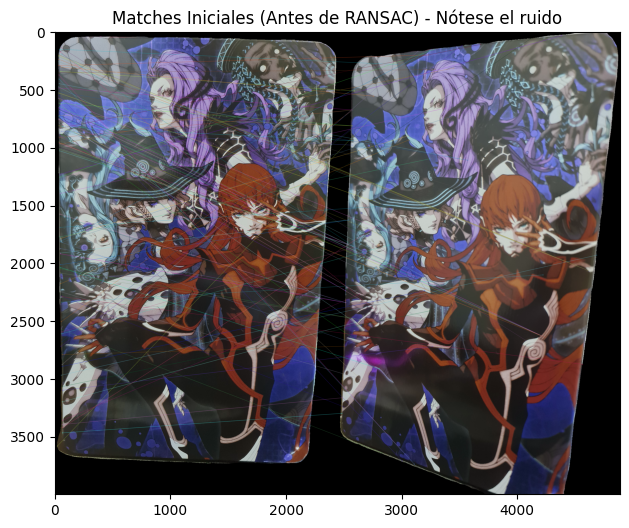

RANSAC finalizado: 348 iteraciones, 2680 inliers encontrados.


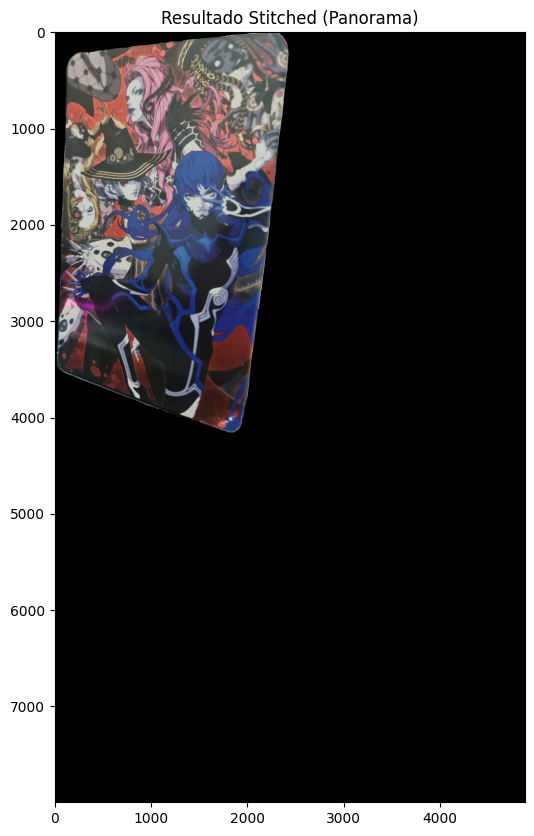

In [9]:
# mostrar resultados
img_ref = cv2.imread('2.png') # destino
img_warp = cv2.imread('1.png') # fuente

# detectar y visualizar
kp_s, kp_d, matches, p_s, p_d = detectar_y_emparejar(img_warp, img_ref)

img_m = cv2.drawMatches(img_warp, kp_s, img_ref, kp_d, matches[:100], None, flags=2)
plt.figure(figsize=(15, 6))
plt.imshow(img_m)
plt.title("Matches Iniciales (Antes de RANSAC) - Nótese el ruido")
plt.show()

#  RANSAC
H_final, _ = ransac_homografia(p_s, p_d)

# Stitching
h, w = img_ref.shape[:2]
pano = cv2.warpPerspective(img_warp, H_final, (w*2, h*2))
pano[0:h, 0:w] = img_ref

plt.figure(figsize=(15, 10))
plt.imshow(cv2.cvtColor(pano, cv2.COLOR_BGR2RGB))
plt.title("Resultado Stitched (Panorama)")
plt.show()

## Task 3

Ahora vamos a variar el parametro del umbral de error para detectar los inliners

In [14]:
thresholds = [0.5,1,5,10,15,20,25,30,35,40,45,50]
liners = []
img_ref = cv2.imread('2.png') # destino
img_warp = cv2.imread('1.png') # fuente
kp_s, kp_d, matches, p_s, p_d = detectar_y_emparejar(img_warp, img_ref)
img_m = cv2.drawMatches(img_warp, kp_s, img_ref, kp_d, matches[:100], None, flags=2)
    
for t in thresholds:
    #  RANSAC
    H_final, mithreshold = ransac_homografia(p_s, p_d, t)
    
    liners.append(mithreshold)

    


RANSAC finalizado: 5001 iteraciones, 259 inliers encontrados.
RANSAC finalizado: 5001 iteraciones, 1100 inliers encontrados.
RANSAC finalizado: 486 iteraciones, 2466 inliers encontrados.
RANSAC finalizado: 309 iteraciones, 2760 inliers encontrados.
RANSAC finalizado: 318 iteraciones, 3124 inliers encontrados.
RANSAC finalizado: 274 iteraciones, 2843 inliers encontrados.
RANSAC finalizado: 171 iteraciones, 3195 inliers encontrados.
RANSAC finalizado: 165 iteraciones, 3223 inliers encontrados.
RANSAC finalizado: 162 iteraciones, 3240 inliers encontrados.
RANSAC finalizado: 159 iteraciones, 3254 inliers encontrados.
RANSAC finalizado: 155 iteraciones, 3274 inliers encontrados.
RANSAC finalizado: 302 iteraciones, 2838 inliers encontrados.


Ahora graficamos

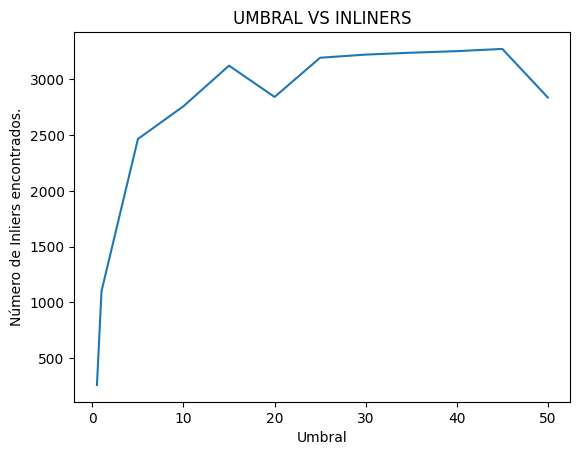

In [15]:
plt.plot(thresholds, liners)
plt.xlabel("Umbral")
plt.ylabel("Número de Inliers encontrados.")
plt.title("UMBRAL VS INLINERS")
plt.show()

**¿Qué riesgo corre si establece un umbral demasiado estricto (ej. 0.5px)?** 


Los riesgos que corremos es que perdamos encontrar mas inliers,y entonces nos quedemos en un minimo local bastante por debajo de lo que deberia ser, como se ve en la grafica anterior despues de 0.5 la cantidad de inliners encontrados es mucho mayor despues siendo un crecimiento exponecial. Esto se traduce como detecciones erroneas y ruido. Incluso la homografia que se encuentre puede ser la peor de todas.

**¿Qué pasa con la matriz final si el umbral es muy laxo (ej. 50px)?**

Lo que pasa aqui es que empezamos tambien a tener ruido, porque como se ve en la grafica de 45 a 50 px, empieza a tener menos inliers lo cual hace que exista mas ruido.

Esto se debe a que estamos capturando mas puntos que en realidad no coinciden con la transformación. Esto hace que se distorcione la solucion obtenida por SVD y entonces la proyección que encontramos esta contaminada con puntos que en realidad no conciden haciendo que la cantidad de inliners disminuya. Por eso como se ve en la grafica lo ideal seria encontrar las planicies, ya que entre ellos no variara la cantidad encontrada.